# Часть 1. Проверка гипотезы в Python и составление аналитической записки

- Автор: Шумилин Андрей Иванович
- Дата: 12.08.2026

## Цели и задачи проекта

<font color='#777778'>Целью проекта является доказательство гипотезы, сформулированной коллегами и проведение анализа результатов A/B тестирования. Задачи включают в себя: 
- выгрузку данных;
- проверку на наличие дубликатов идентификаторов пользователей;
- сравнение размера групп и их статистики, распределения;
- выбор и проведение статистического теста для принятия или отклонения нулевой гипотезы;
- подготовку аналитической записки о результатах проведения такого теста;
- оценку корректности проведения A/B-теста;
- анализ результатов проведенного прошлым аналитиком A/B-теста.</font>

## Описание данных

<font color='#777778'>Таблица `knigi_data` (данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности) содержит следующие столбцы:
- `city` - город пользователя;
- `puid` - уникальный идентификатор пользователя;
- `hours` - сумма часов активности конкретного пользователя.

<font color='#777778'>Таблица `participants` (таблица участников теста) содержит следующие столбцы: 
- `user_id` — идентификатор пользователя;

- `group` — группа пользователя;

- `ab_test` — название теста;

- `device` — устройство, с которого происходила регистрация.</font>

<font color='#777778'>Таблица `events` (таблица с событиями 2020 года) содержит следующие столбцы: 
- `user_id` — идентификатор пользователя;
- `event_dt` — дата и время события;
- `event_name` — тип события;
- `details` — дополнительные данные о событии.</font>


<font color='#777778'>Дополнительная информация по столбцу `details`.


Числовые значения:

| Параметр | Описание |
|----------|----------|
| `registration` | стоимость привлечения клиента |
| `purchase` | стоимость покупки |

Текстовые значения (коды зон):

| Код | Зона | Регион(ы) |
|:---:|------|-----------|
| 0 | `ZONE_CODE00` | None |
| 1 | `ZONE_CODE01` | EU |
| 2 | `ZONE_CODE02` | CIS |
| 3 | `ZONE_CODE03` | EU, CIS |
| 4 | `ZONE_CODE04` | APAC |
| 5 | `ZONE_CODE05` | EU, APAC |
| 6 | `ZONE_CODE06` | CIS, APAC |
| 7 | `ZONE_CODE07` | EU, CIS, APAC |
| 8 | `ZONE_CODE08` | N.America |
| 9 | `ZONE_CODE09` | EU, N.America |
| 10 | `ZONE_CODE10` | CIS, N.America |
| 11 | `ZONE_CODE11` | EU, CIS, N.America |
| 12 | `ZONE_CODE12` | APAC, N.America |
| 13 | `ZONE_CODE13` | EU, APAC, N.America |
| 14 | `ZONE_CODE14` | CIS, APAC, N.America |
| 15 | `ZONE_CODE15` | EU, CIS, APAC, N.America |
    

**Примечание:** зоны могут комбинироваться, что означает принадлежность к нескольким регионам одновременно.</font>

## Содержимое проекта

<font color='#777778'>Проект посвящен проверке продуктовой гипотезы (шаги, они же - задачи - перечислены в пункте про цели и задачи проекта), а также анализу уже проведенного A/B-тестирования (шаги также перечислены в пункте выше).</font>

---

## 1. Загрузка данных и знакомство с ними


In [1]:
# Импортируем все библиотеки для проекта
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest

In [2]:
knigi_data = pd.read_csv('Desktop/knigi_data.csv')

In [3]:
knigi_data

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434
...,...,...,...,...
8779,8779,Санкт-Петербург,1130000028554332,4.107774
8780,8780,Санкт-Петербург,1130000030307246,45.069222
8781,8781,Санкт-Петербург,1130000038726322,0.211944
8782,8782,Санкт-Петербург,1130000047892100,4.311841


## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Статистически докажем это, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

Количество дубликатов идентификаторов пользователей в Москве: 0.
Количество дубликатов идентификаторов пользователей в Санкт-Петербурге: 244.
Дубликатов после удаления: 0.
Размер группы для Москвы: 6234.
Размер группы для Санкт-Петербурга: 2306.
Разница в размерах групп: 3928.

Статистики по группам.

Для Москвы:
count    6234.000000
mean       10.881092
std        36.851683
min         0.000018
25%         0.059903
50%         0.924498
75%         5.939972
max       857.209373
Name: hours, dtype: float64

Для Питера:
count    2306.000000
mean       11.264433
std        39.831755
min         0.000025
25%         0.060173
50%         0.875355
75%         6.138424
max       978.764775
Name: hours, dtype: float64


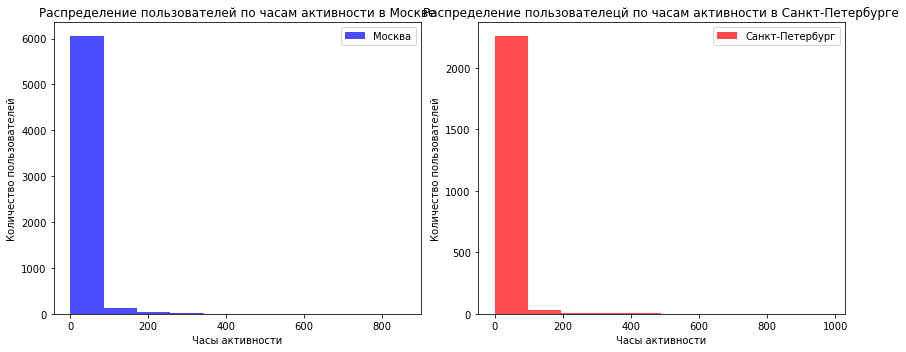

In [7]:
# Посмотрим на количество дубликатов 'puid' в каждом городе
moscow_dubli = knigi_data[(knigi_data['city'] == 'Москва') & (knigi_data.duplicated(subset='puid') == True)]['puid'].count()
piter_dubli = knigi_data[(knigi_data['city'] == 'Санкт-Петербург') & (knigi_data.duplicated(subset='puid') == True)]['puid'].count()
print(f'Количество дубликатов идентификаторов пользователей в Москве: {moscow_dubli}.')
print(f'Количество дубликатов идентификаторов пользователей в Санкт-Петербурге: {piter_dubli}.')

# Удалим дубликаты идентификторов пользователей
clean_df = knigi_data.drop_duplicates(subset='puid', inplace=False)
n = clean_df.duplicated(subset='puid').sum()
print(f'Дубликатов после удаления: {n}.')

# Сравним размеры групп
msk_group = clean_df[clean_df['city'] == 'Москва']
spb_group = clean_df[clean_df['city'] == 'Санкт-Петербург']
print(f'Размер группы для Москвы: {len(msk_group)}.')
print(f'Размер группы для Санкт-Петербурга: {len(spb_group)}.')
print(f'Разница в размерах групп: {len(msk_group) - len(spb_group)}.')

# Сравним статистики групп
print()
print('Статистики по группам.')
print()
print('Для Москвы:')
print(msk_group['hours'].describe())
print()
print('Для Питера:')
print(spb_group['hours'].describe())

# Сравним распределение пользователей по часам активности в группах
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(msk_group['hours'], bins=10, alpha=0.7, label='Москва', color='blue')
plt.title('Распределение пользователей по часам активности в Москве')
plt.xlabel('Часы активности')
plt.ylabel('Количество пользователей')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(spb_group['hours'], bins=10, alpha=0.7, label='Санкт-Петербург', color='red')
plt.title('Распределение пользователецй по часам активности в Санкт-Петербурге')
plt.xlabel('Часы активности')
plt.ylabel('Количество пользователей')
plt.legend()

plt.tight_layout()
plt.show()

Вывод по предварительной работе:
- удалены 244 дубликата по полю `puid` в Санкт-Петербурге, в Москве дублирующихся идентификаторов не оказалось;
- в Москве пользователей сервиса оказалось на 3928 больше, чем в культурной столице: 6234 пользователя в Москве и 3206 в Санкт-Петербурге;
- среднее время суммарной активности пользователя немногим больше в Санкт-Петербурге (11,26 часов), так же как стандартное отклонение (39,83);
- однако медианное значение активности в часах в Москве оказалось больше: 0,92 против 0,87 в культурной столице;
- стоит обратить внимание на серьезное различие медианы и среднего арифметического: дело в том, что медиана устойчива к выбросам, а среднее нет - есть небольшое количество пользователей, которые пользуются сервисом очень много;
- максимальные значения отличаются более чем на 100 часов - рекорд принадлежит питерскому слушателю/читателю (около 979 часов в сумме);
- на гистограмме распределения пользователей по часам активности в городах видна схожая тенденция: скошенное вправо асимметричное распределение с очень высоким столбом от 0 до примерно 80 часов в Москве и от 0 до примерно 100 часов в Санкт-Петербурге. Данный факт характерен для сервисов, подобных исследуемому - очень много людей слушают/читают мало, а мало людей наоборот, слушают/читают много (вплоть до почти 1000 часов). Надо большей аудитории рассылать пуш-уведомления и рекомендации с недолгим контентом, ведь они, скорее всего, не любят долгое чтение. Стоит сказать, что стратегия удержания основных пользователей схожа в двух городах из-за почти одинакового распределения.

In [8]:
alpha = 0.05
stat_welsh_ttest, p_value_welsh_ttest = ttest_ind(
    msk_group['hours'],
    spb_group['hours'],
    equal_var=False,
    alternative='less'
)
if p_value_welsh_ttest >= alpha:
    print(f'Статистика теста Уэлча = {round(stat_welsh_ttest, 2)}')
    print(f'p-value теста Уэлча = {round(p_value_welsh_ttest, 2)}')
    print(f'Нулевая гипотеза верна! В Санкт-Петербурге среднее время активности пользователей не больше, чем в Москве.')
else:
    print(f'Статистика теста Уэлча = {round(stat_welsh_ttest, 2)}')
    print(f'p-value теста Уэлча = {round(p_value_welsh_ttest, 2)}')
    print(f'Нулевая гипотеза отклонена! В Санкт-Петербурге среднее время активности пользователей больше, чем в Москве.')

Статистика теста Уэлча = -0.4
p-value теста Уэлча = 0.34
Нулевая гипотеза верна! В Санкт-Петербурге среднее время активности пользователей не больше, чем в Москве.


## 3. Аналитическая записка

Аналитическая записка после проведенного статистического теста.

- Был выбран t-тест Уэлча, так как дисперсии выборок не равны (стандартные отклонения, как было замечено ранее, не равны), уровень статистической значимости установлен на значении 0.05.


- P-value теста Уэлча оказалось равным примерно 0.34, что больше уровня значимости, а значит отвергнуть нулевую гипотезу нельзя.


- Так как нулевая гипотеза верна, то статистически значим тот факт, что в Санкт-Петербурге среднее время активности пользователей не больше, чем в Москве, то есть предположение коллег не верно (о том, что в Санкт-Петербурге активность больше, чем в столице).


- Хотя средняя активность пользователей в Санкт-Петербурге больше, разница статистически незначима, то есть больше прочесть или прослушать книги люди в культурной столице могли случайно из-за естественной вариативности данных. Причина, вероятно, в высоком стандартном отклонении (степень разброса данных высока), поэтому разница перестает быть закономерностью. Другая причина заключается в размере выборки для Санкт-Петербурга, который меньше почти в 3 раза по сравнению с московской выборкой. Это снижает статистическую мощность теста, то есть способность обнаружить эффект, если он реально есть, из-за чего тест мог не зафиксировать статистически значимую разницу. Если посмотреть на выбросы (аномальные значения), то в Санкт-Петербурге они выше, максимум пиковой активности приходится именно на него, поэтому среднее искуственно завышается ввиду наличия нетипичных пользователей. По этой причине не массовая тенденция виновата, а отдельные юзеры, которые создают иллюзию статистически значимой разницы во времени активности.

# Часть 2. Анализ результатов A/B-тестирования

Теперь нам нужно проанализировать другие данные. Представим, что к нам обратились представители интернет-магазина, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Наша задача — провести оценку результатов A/B-теста. В нашем распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

Оценим корректность проведения теста и проанализируем его результаты.

## 1. Опишем цели исследования.

Основной целью исследования является анализ и оценка результатов уже проведенного A/B-теста. Необходимо понять, корректно ли распределение на группы, оценить размеры выборок, провести статистический тест для проверки изменения конверсии.

## 2. Загрузим данные, оценим их целостность.

In [10]:
participants = pd.read_csv('Desktop/ab_test_participants.csv')
events = pd.read_csv('Desktop/ab_test_events.csv',
                     parse_dates=['event_dt'], low_memory=False)

In [11]:
participants

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac
...,...,...,...,...
14520,FFE7FC140521F5F6,A,interface_eu_test,PC
14521,FFEFC0E55C1CCD4F,A,interface_eu_test,PC
14522,FFF28D02B1EACBE1,B,recommender_system_test,PC
14523,FFF28D02B1EACBE1,B,interface_eu_test,PC


In [12]:
sum_na = participants.isna().sum()
sum_na

user_id    0
group      0
ab_test    0
device     0
dtype: int64

In [13]:
events

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN
...,...,...,...,...
787281,1A655C280B064708,2020-12-31 23:57:44,product_page,NaN
787282,B77B2F4BCA134618,2020-12-31 23:58:23,registration,0.0
787283,GLOBAL,2020-12-31 23:58:30,product_cart,NaN
787284,B12AD1623E494FAD,2020-12-31 23:58:34,registration,-6.52


In [14]:
sum_na = events.isna().sum()
sum_na

user_id            0
event_dt           0
event_name         0
details       538264
dtype: int64

Пропусков в таблице `participants` нет ни в одном столбце - данные полные, соответствуют описанию. Пропуски в таблице `events` есть только в столбце `details`, причем их немало, но так как этот столбец несет в себе лишь дополнительную информацию, наличие пропусков некритично, данные соответствуют описанию.

## По таблице `ab_test_participants` оценим корректность проведения теста:

3.1 Выделим пользователей, участвующих в тесте, и проверим:

соответствие требованиям технического задания,

равномерность распределения пользователей по группам теста,

отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

In [15]:
# Берем только нужный тест
test_participants = participants[participants['ab_test'] == 'interface_eu_test']

# Группы, участвующие в тесте
print('Группы в тесте:', test_participants['group'].unique())

# Количество пользователей в каждой группе
print(test_participants['group'].value_counts())

Группы в тесте: ['B' 'A']
B    5467
A    5383
Name: group, dtype: int64


In [16]:
# Считаем распределение пользователей по группам
group_counts = test_participants['group'].value_counts()
group_percents = round(100 * group_counts / len(test_participants), 2)

print('Распределение по группам в %:')
print(group_percents)

Распределение по группам в %:
B    50.39
A    49.61
Name: group, dtype: float64


# Пользователи, участвующие в другом тесте

In [17]:
users_in_other_tests = participants[participants['ab_test'] != 'interface_eu_test']['user_id']

# Проверяем, есть ли пользователи из нашего теста в этом списке

In [18]:
our_users = test_participants['user_id']
intersection = set(our_users) & set(users_in_other_tests)

print(f'Пользователей, участвующих одновременно в двух тестах: {len(intersection)}')

Пользователей, участвующих одновременно в двух тестах: 887


In [19]:
# Проверяем пересечение в группах
group_A = test_participants[test_participants['group'] == 'A']['user_id']
group_B = test_participants[test_participants['group'] == 'B']['user_id']
intersection_groups = set(group_A) & set(group_B)

print(f'Пользователей, находящихся одновременно в двух группах теста: {len(intersection)}')

Пользователей, находящихся одновременно в двух группах теста: 887


In [20]:
# Очистим данные от пользователей, находящихся в других тестах
clean_participants = test_participants[~test_participants['user_id'].isin(users_in_other_tests)]

# Смотрим пересечение пользователей по тестам после очистки
inter_tests = set(users_in_other_tests) & set(clean_participants['user_id'])
print(f'Пользователей, которые одновременно участвуют в обеих тестах: {len(inter_tests)}.')

# Очистим данные от пользователей, находящихся в обеих группах
users_in_both_groups = clean_participants.groupby('user_id')['group'].nunique()
users_in_both_groups = users_in_both_groups[users_in_both_groups > 1].index.tolist()
clean_participants = clean_participants[~clean_participants['user_id'].isin(users_in_both_groups)]

# Смотрим пересечение пользователей по группам после очистки 
inter_groups = set(clean_participants[clean_participants['group'] == 'A']['user_id']) & set(clean_participants[clean_participants['group'] == 'B']['user_id'])
print(f'Пользователей, которые одновременно участвуют в обеих группах: {len(inter_groups)}.')

Пользователей, которые одновременно участвуют в обеих тестах: 0.
Пользователей, которые одновременно участвуют в обеих группах: 0.


Процентное соотношение пользователей близко к 50% в обеих группах, выборки соответствуют ТЗ, удалены пользователи, находящиеся в обеих группах и участвующие в двух тестах одновременно, поэтому пересечений нет, а значит выборки валидны для проведения теста (до очистки были невалидны).

3\.2 Проанализируем данные о пользовательской активности по таблице `ab_test_events`:

- оставим только события, связанные с участвующими в изучаемом тесте пользователями;

In [21]:
# Оставляем в таблице в событиями только пользователей, которые участвуют в тесте
events_with_test_users = events[events['user_id'].isin(clean_participants['user_id'])]
events_with_test_users

,user_id,event_dt,event_name,details
64672,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0
64946,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8
66585,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32
67873,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48
67930,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0
...,...,...,...,...
777479,F80C9BDDEA02E53C,2020-12-30 10:02:43,purchase,4.49
777488,F80C9BDDEA02E53C,2020-12-30 10:03:51,purchase,4.49
777489,F80C9BDDEA02E53C,2020-12-30 10:03:52,product_cart,NaN
778138,6181F3835EBE66BF,2020-12-30 12:10:39,product_cart,NaN


- определим горизонт анализа: рассчитаем время (лайфтайм) совершения события пользователем после регистрации и оставим только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [22]:
# Создадим датафрейм с датами регистраций
events_reg_date = events_with_test_users[events_with_test_users['event_name'] == 'registration'][['user_id', 'event_dt']]
# Переименуем поле с датой
events_reg_date.columns = ['user_id', 'reg_dt']

# Присоединим дату регистрации ко всем событиям
events_with_reg_date = events_with_test_users.merge(events_reg_date, on='user_id', how='left')

# Добавляем время совершения события
events_with_reg_date['day'] = (events_with_reg_date['event_dt'] - events_with_reg_date['reg_dt']).dt.days

# Оставляем события только за первые 7 дней
events_7_days = events_with_reg_date[(events_with_reg_date['day'] >= 0) & (events_with_reg_date['day'] <= 6)]

Оценим достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [23]:
alpha = 0.05
beta = 0.2
power = 0.8
p = 0.3
mde = 0.03
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 3761


Для корректного проведения A/B-теста требуется в каждой группе иметь хотя бы по 3761 пользователя. В группе А 5383 пользователя, а в группе B - 5467. Следовательно, размеры групп подходящие, по этой части вопросов к подготовке теста нет.

- рассчитаем для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [37]:
# Присоединим в таблицу с событиями за первые 7 дней после регистрации информацию о группах пользователей 
df_groups = clean_participants[['user_id', 'group']]
events_7_days = events_7_days.merge(df_groups, on='user_id', how='left')

In [38]:
# Расчет покупателей и общего количества посетителей для группы А
purchasers_group_A = events_7_days[(events_7_days['group'] == 'A') & (events_7_days['event_name'] == 'purchase')]
buy_count_A = purchasers_group_A['user_id'].nunique()
count_A = len(clean_participants[clean_participants['group'] == 'A'])
print(f'Количество покупателей в группе А: {buy_count_A}.')
print(f'Количество посетителей в группе А: {count_A}.')
print(40*'=')
# Расчет покупателей и общего количества посетителей для группы B
purchasers_group_B = events_7_days[(events_7_days['group'] == 'B') & (events_7_days['event_name'] == 'purchase')]
buy_count_B = purchasers_group_B['user_id'].nunique()
count_B = len(clean_participants[clean_participants['group'] == 'B'])
print(f'Количество покупателей в группе B: {buy_count_B}.')
print(f'Количество посетителей в группе B: {count_B}.')

Количество покупателей в группе А: 1377.
Количество посетителей в группе А: 4952.
Количество покупателей в группе B: 1480.
Количество посетителей в группе B: 5011.


- сделаем предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

In [39]:
# Расчет конверсии из посетителей в покупателей за первые 7 дней после регистрации для котнрольной группы
conversion_A = round(buy_count_A / count_A * 100, 2)
print(f'Конверсия из посетителей в покупателей за первые 7 дней после регистрации для котнрольной группы составила: {conversion_A}%')

# Расчет конверсии из посетителей в покупателей за первые 7 дней после регистрации для тестовой группы
conversion_B = round(buy_count_B / count_B * 100, 2)
print(f'Конверсия из посетителей в покупателей за первые 7 дней после регистрации для тестовой группы составила: {conversion_B}%')

Конверсия из посетителей в покупателей за первые 7 дней после регистрации для котнрольной группы составила: 27.81%
Конверсия из посетителей в покупателей за первые 7 дней после регистрации для тестовой группы составила: 29.54%


По полученным значениям конверсии можно предварительно заключить: пользовательская активность выросла. В тестовой группе был достигнут следующий результат: 29,54% пользователей стали покупателями. Это больше почти на 1,73% по сравнению с конверсией в контрольной группе: 27,81%. Следовательно, однозначно можно зафиксировать увеличение числа покупателей в течение 7 дней после регистрации для выборки с упрощенным интерфейсом. Изменение меньше запланированного минимального детектируемого эффекта, что не подтверждает гипотезу об увеличении конверсии минимум на 3 п.п. Кроме того, нужна статистическая проверка: вдруг изменение на 1,73% оказалось случайным.

## 4. Проведем оценку результатов A/B-тестирования:

- Проверим изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

Используем именно z-тест пропорций, так как целевая метрика - долевая (отношение успехов - купил - ко всем исходам).

In [40]:
# Рассчитаем доли успехов для каждой из групп A и B
p_A = buy_count_A / count_A
p_B = buy_count_B / count_B

# Проверим предпослыку о достаточном количестве данных
if (p_A * count_A > 10) and ((1 - p_A) * count_A > 10) and (p_B * count_B > 10) and ((1 - p_B) * count_B > 10):
    print('Предпосылка о достаточном количестве данных выполняется!')
else: 
    print('Предпосылка о достаточном количестве данных не выполняется!')
print()
    
# Проведем z-тест пропорций
alpha = 0.05
stat_ztest, p_value_ztest = proportions_ztest(
    [buy_count_A, buy_count_B],
    [count_A, count_B],
    alternative='smaller'
)

if p_value_ztest >= alpha:
    print(f'p-value={p_value_ztest} > {alpha}')
    print('Нулевая гипотеза находит подтверждение!')
else:
    print(f'p-value={p_value_ztest} < {alpha}')
    print('Нулевая гипотеза не находит подтверждение!')

Предпосылка о достаточном количестве данных выполняется!

p-value=0.028262547212292124 < 0.05
Нулевая гипотеза не находит подтверждение!


После проведения оценки результатов A/B-тестирования можно сделать вывод: увеличение конверсии на 1,73% в группе с упрощенным интерфейсом является статистически значимым. Целевой рост метрики достигнут не был, но даже небольшой рост способствует развитию бизнеса, поэтому рекомендовать ко внедрению улучшение интерфейса можно. Доля платящих пользователей в тестовой группе статистически значимо больше, чем в тестовой. Значит предположение коллег, в основе которого лежит более понятное взаимодействие с сервисом, верно, хотя и не был достигнут минимальный эффект.